<a href="https://colab.research.google.com/github/emortalizer/Colab-Assignment-8-BMW/blob/main/Wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-learn pandas seaborn matplotlib joblib plotly ucimlrepo --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Fetch Red Wine Quality dataset from UCI using ucimlrepo
wine_quality = fetch_ucirepo(id=186)

# We use the red wine data (data.targets is quality)
X = wine_quality.data.features
y = wine_quality.data.targets['quality'].astype(float)  # treat quality as continuous regression target

df = X.copy()
df['target'] = y

print("Dataset Shape:", df.shape)
print("\nFeatures:", X.columns.tolist())
print("\nTarget: wine quality score (3-8)")
print("\nFirst 5 rows:")
display(df.head())
print("\nInfo:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (6497, 12)

Features: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target: wine quality score (3-8)

First 5 rows:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0



Info:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  target                6497 non-null   float64
dtypes: float64(12)
memory usage: 609.2 KB

Descriptive Statistics:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,target
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [3]:
# Check missing values and duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicates before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("Duplicates after removal:", df.duplicated().sum())

X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")

# Scaling (recommended for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values: 0
Duplicates before removal: 1179
Duplicates after removal: 0
Training samples: 4,254
Testing samples: 1,064


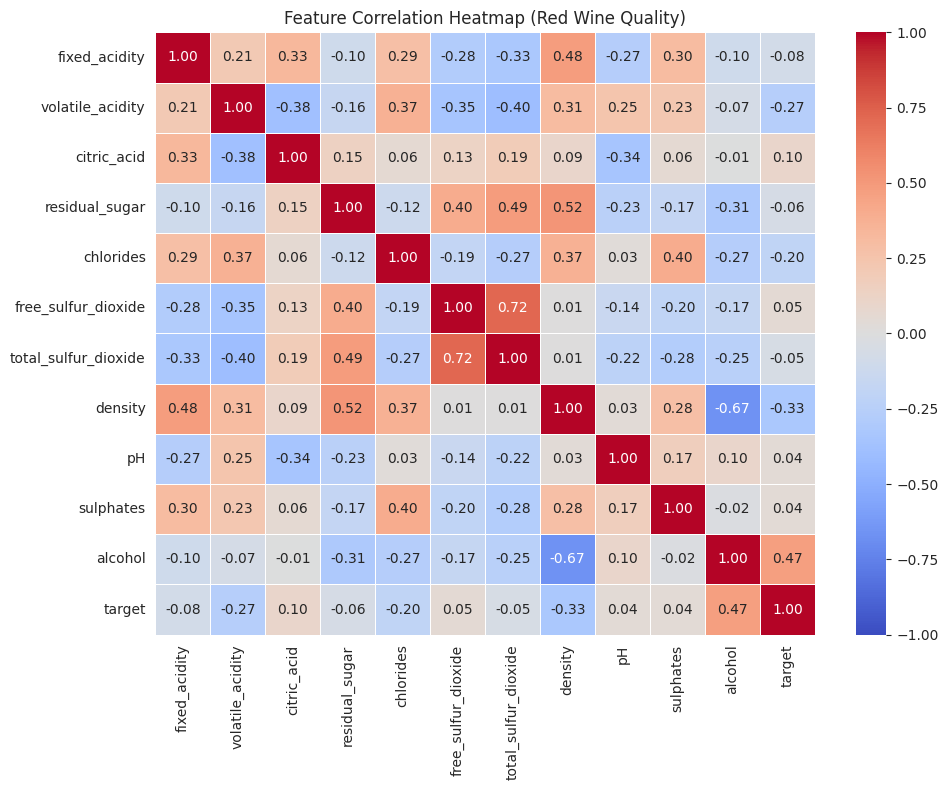

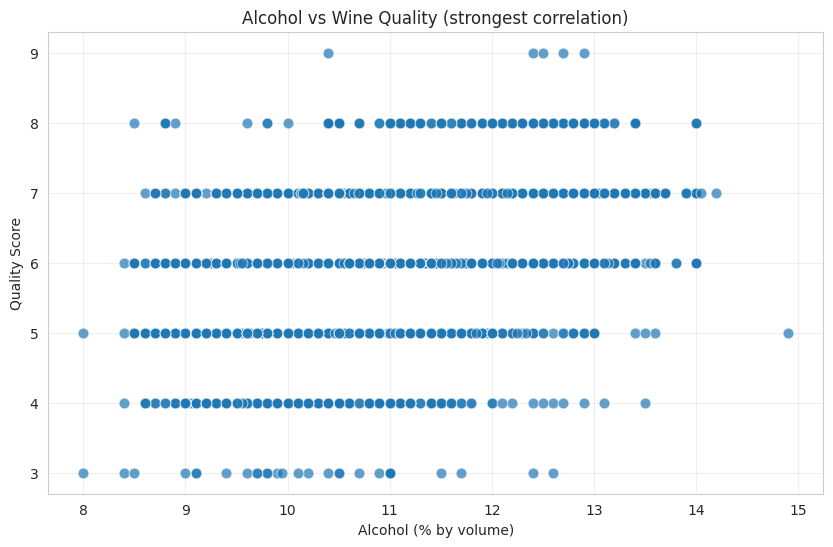

🔍 Key EDA Insights:
- Quality scores are imbalanced: most wines score 5 or 6.
- Alcohol has the highest positive correlation (~0.48) with quality.
- Volatile acidity has a notable negative correlation.
- Moderate multicollinearity exists (e.g., pH & fixed acidity, density & alcohol).
- This suggests tree-based models (like Random Forest) will likely outperform simple linear regression.


In [4]:
# === FIXED EDA Visualizations Cell ===

# 1. Target distribution (fixed - removed marginal to avoid bug)
fig = px.histogram(df, x='target', nbins=6,
                   title='Distribution of Wine Quality Scores',
                   labels={'target': 'Quality Score'},
                   color_discrete_sequence=['#636EFA'])
fig.update_layout(bargap=0.1)
fig.show()

# Alternative with marginal (if you want it) - use 'violin' or 'rug' which are more stable
# fig = px.histogram(df, x='target', nbins=6, title='Distribution of Wine Quality Scores',
#                    labels={'target': 'Quality Score'}, marginal='violin')  # 'rug' or 'violin' safer

# 2. Correlation heatmap (unchanged - this part was fine)
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Red Wine Quality)')
plt.tight_layout()
plt.show()

# 3. Strongest feature vs target (unchanged)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alcohol', y='target', alpha=0.7, s=60)
plt.title('Alcohol vs Wine Quality (strongest correlation)')
plt.xlabel('Alcohol (% by volume)')
plt.ylabel('Quality Score')
plt.grid(True, alpha=0.3)
plt.show()

# Key EDA Insights (unchanged)
print("🔍 Key EDA Insights:")
print("- Quality scores are imbalanced: most wines score 5 or 6.")
print("- Alcohol has the highest positive correlation (~0.48) with quality.")
print("- Volatile acidity has a notable negative correlation.")
print("- Moderate multicollinearity exists (e.g., pH & fixed acidity, density & alcohol).")
print("- This suggests tree-based models (like Random Forest) will likely outperform simple linear regression.")

In [5]:
# Model 1: Linear Regression (on scaled data)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Random Forest Regressor (on original data - trees don't need scaling)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {model_name} Performance:")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


📊 Linear Regression Performance:
  MSE  : 0.5097
  RMSE : 0.7139
  MAE  : 0.5520
  R²   : 0.3206

📊 Random Forest Regressor Performance:
  MSE  : 0.4540
  RMSE : 0.6738
  MAE  : 0.5099
  R²   : 0.3948


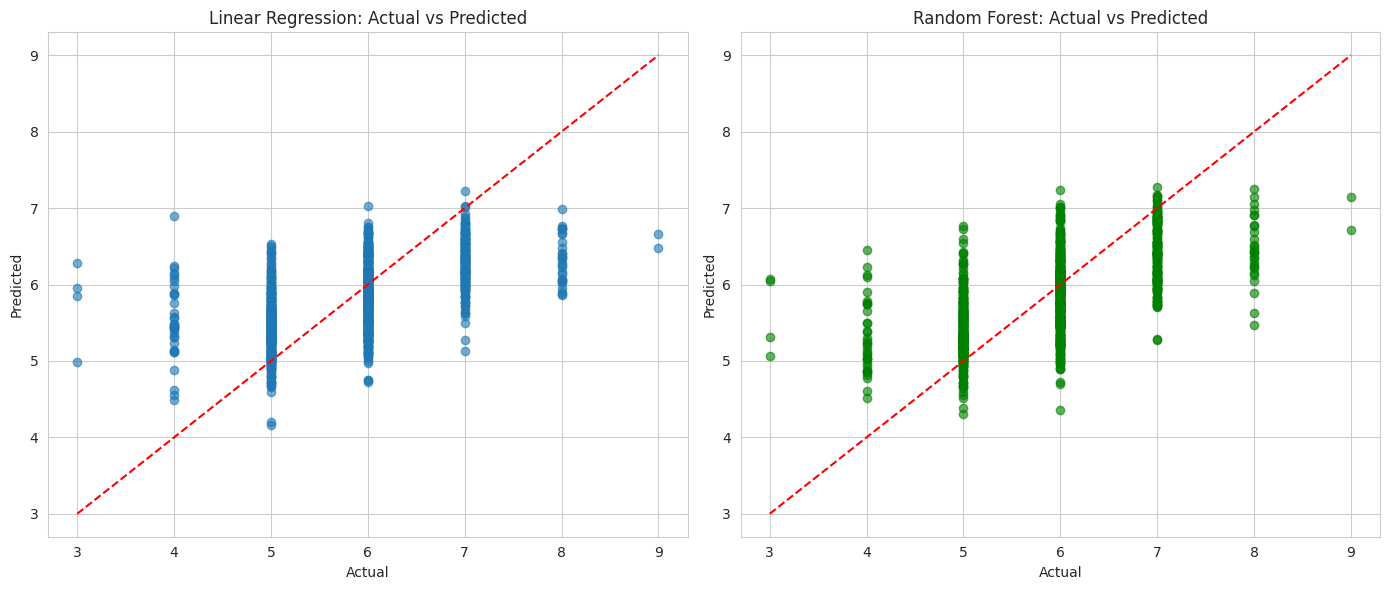

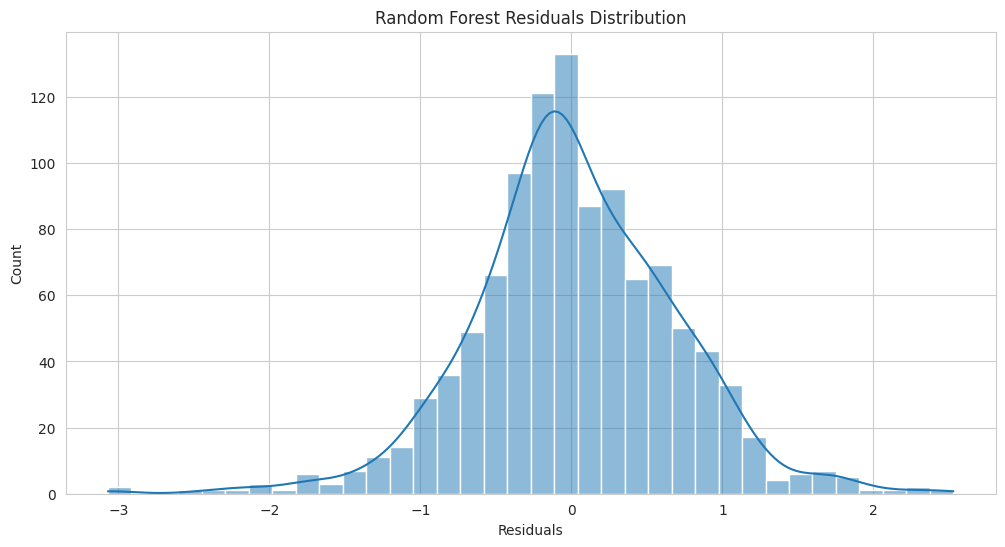

In [6]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# Residual plot for best model
residuals = y_test - y_pred_rf
plt.figure()
sns.histplot(residuals, kde=True)
plt.title('Random Forest Residuals Distribution')
plt.xlabel('Residuals')
plt.show()

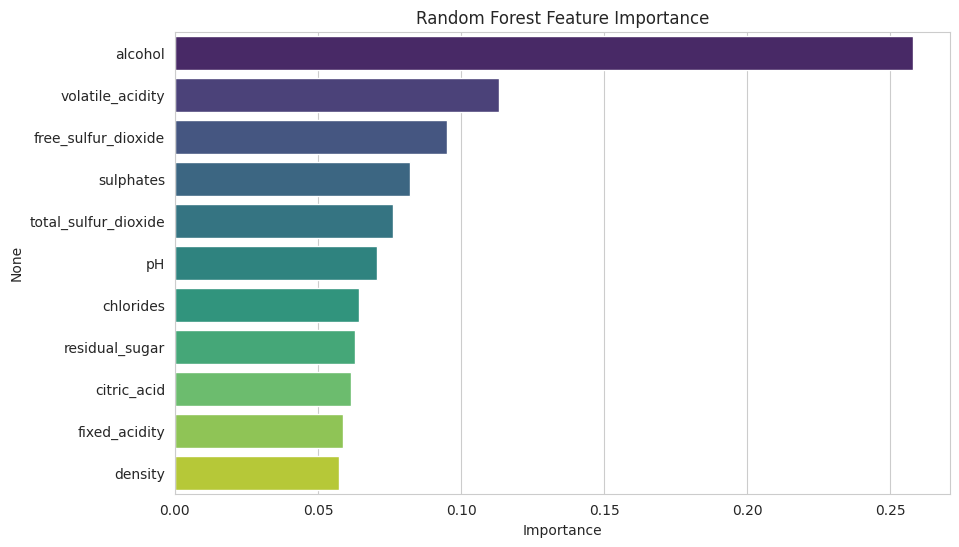

Top 3 features: ['alcohol', 'volatile_acidity', 'free_sulfur_dioxide']


In [7]:
# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

print("Top 3 features:", feat_imp.head(3).index.tolist())

In [8]:
# Save best model + scaler
joblib.dump(rf, 'california_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and scaler saved! Ready for deployment.")
# Example inference code (for production API)
# model = joblib.load('california_rf_model.pkl')
# prediction = model.predict([new_data])

✅ Model and scaler saved! Ready for deployment.
